Kelompok :

Ihsan Maulana Prasetia

Muhammad Rifki Apreliant

Prima Uziel Nasution

In [7]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Ganti 'nama_file_anda.csv' dengan nama file CSV Anda dan 'nama_kolom_target' dengan kolom target Anda
csv_file_name = '/content/HeartDiseaseTrain-Test.csv' # Contoh: 'iris.csv' atau 'diabetes.csv'
target_column = 'nama_kolom_target' # Ini akan ditimpa oleh sel berikutnya, namun untuk kelengkapan.

try:
    df = pd.read_csv(csv_file_name)
    print(f"Data berhasil dimuat dari '{csv_file_name}'.")
    print("Informasi Dataset:")
    df.info()
    print("\n5 Baris Pertama Data:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: File '{csv_file_name}' tidak ditemukan. Pastikan file berada di direktori yang benar atau ganti dengan nama file yang sesuai.")
    print("Anda dapat mengunggah file CSV Anda atau menggunakan salah satu dari sample_data:")
    print("\nContoh file di /content/sample_data/:")
    !ls /content/sample_data/

Data berhasil dimuat dari '/content/HeartDiseaseTrain-Test.csv'.
Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flour

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [8]:
# Update target_column based on user input
target_column = 'target'
print(f"Kolom target diatur ke: '{target_column}'")

Kolom target diatur ke: 'target'


### 1. Preprocessing Data

Langkah pertama adalah memisahkan fitur (X) dan target (y). Kita juga akan mengecek tipe data dan menangani jika ada kolom non-numerik yang perlu di-encode.

In [9]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=[target_column])
y = df[target_column]

# Identifikasi kolom kategorikal (jika ada)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    print("Kolom kategorikal ditemukan, akan dilakukan One-Hot Encoding:", categorical_cols.tolist())
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
else:
    print("Tidak ada kolom kategorikal yang ditemukan atau sudah numerik.")

# Periksa missing values
print("\nMissing values sebelum imputasi:")
print(X.isnull().sum()[X.isnull().sum() > 0])

# Imputasi missing values dengan median (untuk fitur numerik)
# Hanya imputasi jika ada missing values
for col in X.columns:
    if X[col].isnull().any():
        if X[col].dtype == 'float64' or X[col].dtype == 'int64':
            median_val = X[col].median()
            X[col].fillna(median_val, inplace=True)
            print(f"Missing values di kolom '{col}' diisi dengan median: {median_val}")
        else:
            # Untuk tipe data lain, bisa menggunakan mode atau strategi lain
            print(f"Kolom '{col}' memiliki missing values tetapi bukan numerik, perlu penanganan khusus.")

print("\nMissing values setelah imputasi:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Kolom kategorikal ditemukan, akan dilakukan One-Hot Encoding: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']

Missing values sebelum imputasi:
Series([], dtype: int64)

Missing values setelah imputasi:
Series([], dtype: int64)


### 2. Membagi Data Latih dan Data Uji

Data akan dibagi menjadi 80% data latih dan 20% data uji.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran data latih (X_train): {X_train.shape}")
print(f"Ukuran data uji (X_test): {X_test.shape}")
print(f"Distribusi kelas di y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Distribusi kelas di y_test:\n{y_test.value_counts(normalize=True)}")

Ukuran data latih (X_train): (820, 22)
Ukuran data uji (X_test): (205, 22)
Distribusi kelas di y_train:
target
1    0.513415
0    0.486585
Name: proportion, dtype: float64
Distribusi kelas di y_test:
target
1    0.512195
0    0.487805
Name: proportion, dtype: float64


### 3. Klasifikasi Menggunakan Decision Tree

Kita akan membangun model Decision Tree dengan `max_depth=3` untuk pruning (pemangkasan).

In [11]:
# Inisialisasi dan latih model Decision Tree dengan max_depth=3
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_dt = dtc.predict(X_test)

# Evaluasi Model Decision Tree
print("\n--- Evaluasi Model Decision Tree ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


--- Evaluasi Model Decision Tree ---
Accuracy: 0.8537

Confusion Matrix:
[[82 18]
 [12 93]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       100
           1       0.84      0.89      0.86       105

    accuracy                           0.85       205
   macro avg       0.86      0.85      0.85       205
weighted avg       0.85      0.85      0.85       205



### Visualisasi Pohon Keputusan (Decision Tree)

Berikut adalah visualisasi pohon keputusan yang telah dipangkas dengan `max_depth=3`.

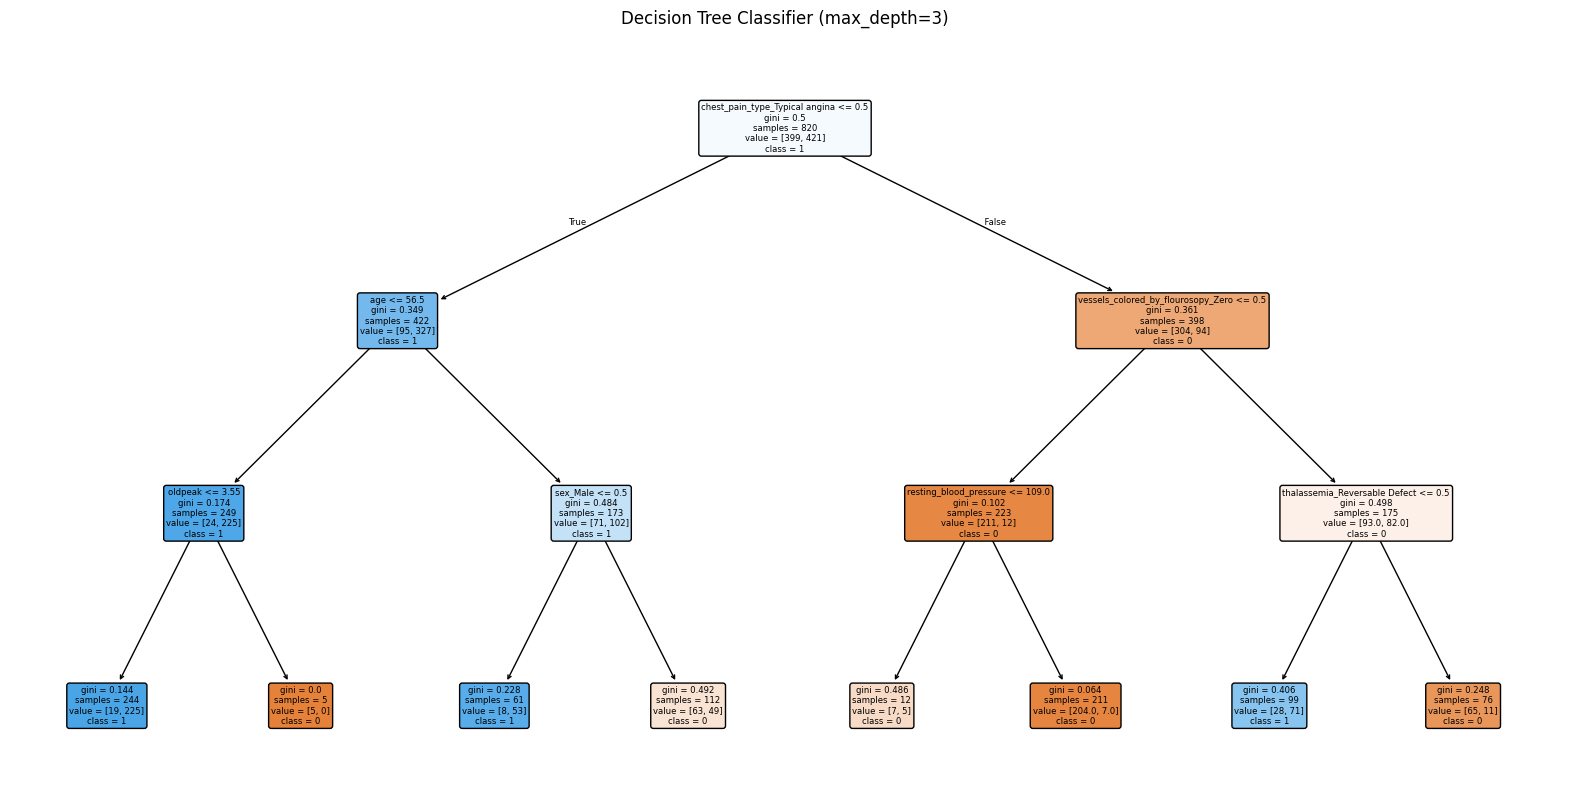

In [12]:
plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=X.columns.tolist(), class_names=[str(c) for c in dtc.classes_], rounded=True)
plt.title("Decision Tree Classifier (max_depth=3)")
plt.show()

### 4. Klasifikasi Menggunakan Random Forest

Sekarang kita akan membangun model Random Forest. Kita juga akan menjelaskan pengaruh `n_estimators`.

In [13]:
# Inisialisasi dan latih model Random Forest
# n_estimators adalah jumlah pohon keputusan dalam forest
# Secara default, scikit-learn menggunakan 100 pohon. Kita akan gunakan 100 untuk contoh ini.
# Anda bisa mencoba nilai yang berbeda untuk melihat pengaruhnya.

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_rf = rfc.predict(X_test)

# Evaluasi Model Random Forest
print("\n--- Evaluasi Model Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


--- Evaluasi Model Random Forest ---
Accuracy: 1.0000

Confusion Matrix:
[[100   0]
 [  0 105]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



### Penjelasan Pengaruh `n_estimators` pada Random Forest

Parameter `n_estimators` dalam Random Forest menentukan jumlah pohon keputusan yang akan dibangun dalam 'hutan' (forest). Setiap pohon dibangun secara independen, dan prediksi akhir (untuk klasifikasi) biasanya ditentukan oleh voting mayoritas dari prediksi masing-masing pohon.

*   **Meningkatkan `n_estimators`**: Umumnya akan meningkatkan kinerja model dan stabilitas, karena semakin banyak pohon yang berpartisipasi dalam voting, semakin kecil kemungkinan kesalahan bias dari satu pohon. Ini membantu mengurangi varians dan mencegah *overfitting*.
*   **Batas `n_estimators`**: Namun, ada titik di mana penambahan lebih banyak pohon tidak lagi memberikan peningkatan signifikan pada kinerja model. Sebaliknya, hanya akan meningkatkan waktu komputasi dan penggunaan memori.
*   **Overfitting**: Meskipun `n_estimators` yang tinggi dapat mengurangi varians, Random Forest secara umum cenderung tidak *overfit* dengan penambahan pohon karena prinsip *bagging* dan *random subspace* yang digunakannya. Namun, perlu menemukan keseimbangan antara kinerja dan efisiensi komputasi.

### 5. Perbandingan Hasil Kedua Model

Mari kita bandingkan akurasi dan metrik lainnya dari kedua model.


--- Perbandingan Akurasi Model ---
Accuracy Decision Tree: 0.8537
Accuracy Random Forest: 1.0000


/tmp/ipykernel_6350/3960473154.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


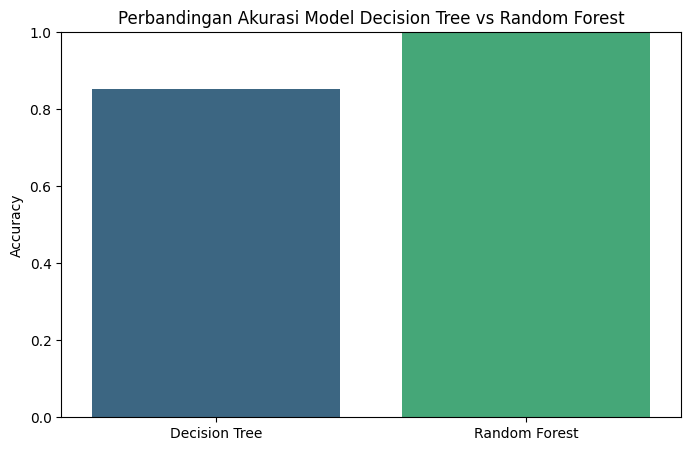


--- Penjelasan Perbedaan Hasil ---
Secara umum, Random Forest seringkali memiliki akurasi yang lebih tinggi dan lebih tahan terhadap overfitting dibandingkan Decision Tree tunggal.
Ini karena Random Forest merupakan ensemble dari banyak Decision Tree yang bekerja bersama-sama. Setiap pohon dalam Random Forest dibangun dari subset data dan fitur yang berbeda secara acak, dan prediksi akhirnya didasarkan pada voting mayoritas atau rata-rata, yang membantu mengurangi bias dan varians.
Decision Tree tunggal, terutama yang tidak dipangkas (pruned), cenderung lebih mudah overfit pada data latih, meskipun dalam kasus ini kita telah membatasinya dengan `max_depth=3`.


In [14]:
print("\n--- Perbandingan Akurasi Model ---")
print(f"Accuracy Decision Tree: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Accuracy Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")

# Visualisasi perbandingan akurasi
models = ['Decision Tree', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Perbandingan Akurasi Model Decision Tree vs Random Forest')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1
plt.show()

print("\n--- Penjelasan Perbedaan Hasil ---")
print("Secara umum, Random Forest seringkali memiliki akurasi yang lebih tinggi dan lebih tahan terhadap overfitting dibandingkan Decision Tree tunggal.")
print("Ini karena Random Forest merupakan ensemble dari banyak Decision Tree yang bekerja bersama-sama. Setiap pohon dalam Random Forest dibangun dari subset data dan fitur yang berbeda secara acak, dan prediksi akhirnya didasarkan pada voting mayoritas atau rata-rata, yang membantu mengurangi bias dan varians.")
print("Decision Tree tunggal, terutama yang tidak dipangkas (pruned), cenderung lebih mudah overfit pada data latih, meskipun dalam kasus ini kita telah membatasinya dengan `max_depth=3`.")